In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import numpy.random as rd
from fractions import *
import scipy as sp
from functools import *
from IPython.display import display, Math
from scipy.integrate import odeint
import timeit
import h5py 
import torch
import torch.nn as nn

In [2]:
mo = 3
c =  1.0
n =  1
N =  1000000
n_cross = 2 
a0 = 1.0
sa = 0.1 
b0 =  1.0
sb =  0.1
s1 =  0.1
s2 = 1.5
phi_range = np.pi  
phidotin = 0.0
# ain = 0.00000001
ain = 1e-8
afi = 1.0
rhocrit = 3.0 
rho_m0 = 0.81 
scaling_factor = 1 #1e-10
rho_r0 = 0.00027138 * scaling_factor
rho_l0 = 2.19 * scaling_factor
rhol = rho_l0 
t_in = 0.0
t_fi = 1.0
t = np.linspace(t_in, t_fi, N)

# axion mass
ma0 = 1e5

[5000000000.0]
[1.0, 0.0, 5000000000.0, 1e-08]


<IPython.core.display.Math object>

1.0 0.0 5000000000.0 1e-08


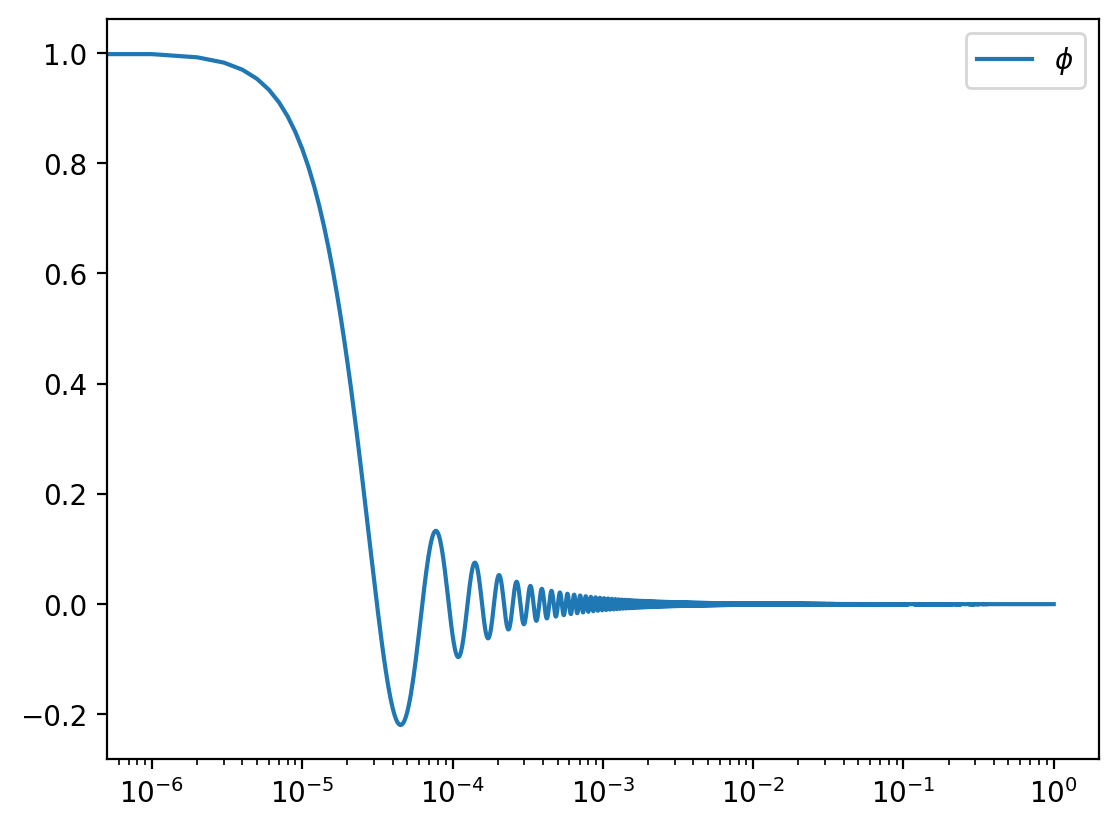

axion mass [100000.]


In [3]:
def diag(mo,c,n,a0,b0,sa,sb,s1,s2,phi_range,phidotin):
	if mo == 3:

        ######################################
		####          Kahler              ####
		######################################

		k = (a0/np.random.uniform(s1,s2,(n,n))) #random matrix k from log normal distribution
		kT = k.transpose() # transpose of random matrix k
		k2 = np.dot(k,kT)  # Construction of symmeterised Kahler matric for real axion fields
		ev,pT = np.linalg.eigh(k2) # calculation of eigen values and eigen vectors
		fef = np.sqrt(ev)
		p = pT.transpose() # tranpose of rotational matrix constructed of eigen vectors
		kD = reduce(np.dot, [p, k2, pT]) #diagonalisation of Kahler metric
		kD[kD < 1*10**-13] = 0 # removal of computational error terms in off diagonal elements
		kDr = np.zeros((n, n))#creation of empty 3x3 matrix
		np.fill_diagonal(kDr, (1/((2**0.5)*np.sqrt(ev))))# matrix for absolving eigen values of kahler metric into axion fields
		#kDr[kDr > 1*10**23] = 0 # remove computational errors in reciprocal matrix
		kDrT = kDr.transpose() # trasnpose of kDr matrix

		######################################
		####            Mass              ####
		######################################

		m = (np.random.uniform(np.log(b0)-sb,np.log(b0)+sb,(n,n))) #random matrix m from log normal distribution
		mm = np.exp(-m)
		mT = mm.transpose() # transpose of random matrix m
		m2 = np.dot(mm,mT) # symmeterised mass matrix from real axion fields
		mn = reduce(np.dot, [pT,kDrT, m2, kDr,p]) # correct mass matrix caclulation
		ma_array,mv = np.linalg.eigh(mn) # reout of masses from eigenvalues of mn


	phiin_array = rd.uniform(-phi_range,phi_range,n)

	for i in range (0,n):
		phiin_array[i] = phiin_array[i]*fef[i]
	phiin_array=np.dot(mv,phiin_array)

	phidotin_array = [phidotin]*n #### array of phidotin where all are set equal to zero

	####################################################################
	####################################################################

		
	return ma_array,fef,phiin_array,phidotin_array

def rhoinitial(phidotin_array,phiin_array,ma_array,n):
    rhoin_array=[]
#     print(phidotin_array,phiin_array,ma_array,n)
    for i in range(n):	
        rhoin_array.append( 0.5*phidotin_array[i]**2 + 0.5*(ma_array[i]**2)*phiin_array[i]**2 )
    return rhoin_array
	
###################################################################	

###################################################################
####                    Initial y array                        ####
###################################################################
	
def yinitial(n,phiin_array,phidotin_array,rhoin_array,ain):
	y0=[]
	for i in range(n):
		y0.append(phiin_array[i])
		y0.append(phidotin_array[i])
		y0.append(rhoin_array[i])
	y0.append(ain)
#	print(y0)
	return y0	

def deriv_rho(y,t,n,ma_array,rho_m0,rho_r0,rhol): 
	func=[]
	rho_ax=sum(y[:-1])
	for i in range(n):
		if np.sqrt(3)*np.sqrt(rho_ax + rho_m0/y[-1]**3 + rho_r0/y[-1]**4 + rhol) > 2*(ma_array[i]):
			func.append((-3/np.sqrt(3)*np.sqrt(rho_ax + rho_m0/y[-1]**3 + rho_r0/y[-1]**4 + rhol)*(1-1)*(y[i])))
		else:
			func.append((-3/np.sqrt(3)*np.sqrt(rho_ax + rho_m0/y[-1]**3 + rho_r0/y[-1]**4 + rhol)*(y[i])))	
	func.append((1/np.sqrt(3)*np.sqrt(rho_ax*y[-1]**2 + rho_m0/y[-1] + rho_r0/y[-1]**2 + rhol*y[-1]**2)))
	return func



def deriv_wfromphi(y, t, n, n_cross, ma_array, rho_m0, rho_r0, rhol):
#def deriv_wfromphi(y, ma_array):
#
    crossing_index = [0]*n
    func = []
    rho_ax = sum(y[2::3])  # ใช้ y แทน y ในการเข้าถึงค่าตัวแปร
#
    for i in range(n):
        if (crossing_index[i] % 2 == 0 and ma_array[i] * y[3*i] * y[3*i] < y[3*i+1] * y[3*i+1] and y[3*i+1] > 0) or \
           (crossing_index[i] % 2 == 1 and ma_array[i] * y[3*i] * y[3*i] > y[3*i+1] * y[3*i+1] and y[3*i+1] < 0):
            crossing_index[i] += 1
        
        func.append(y[3*i+1])  
        if crossing_index[i] < n_cross:
            func.append((-np.sqrt(3) * (np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol)) * y[3*i+1] - (ma_array[i]**2) * y[3*i]))
        else:
            func.append(-np.sqrt(3) * (np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol)) * y[3*i+1])
        
        if crossing_index[i] < n_cross:
            func.append(-3 / np.sqrt(3) * np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol) * y[3*i+1]**2)
        else:
            func.append(-3 / np.sqrt(3) * np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol) * y[3*i+2])

    func.append((1 / np.sqrt(3) * np.sqrt(rho_ax * (y[-1])**2 + rho_m0 / y[-1] + rho_r0 / y[-1]**2 + rhol * (y[-1])**2)))

#     print(crossing_index)

    return func

def eq(y,t):
    return deriv_wfromphi(y,t,n,n_cross,ma_array,rho_m0,rho_r0,rhol)


ma_array, fef, phiin_array, phidotin_array = diag(mo, c, n, a0, b0, sa, sb, s1, s2, phi_range, phidotin)
ma_array = np.array([ma0])
phiin_array = np.array([1.0])
rhoin_array = rhoinitial(phidotin_array, phiin_array, ma_array, n)
# print(rhoin_array)
# rhoin_array = np.array([5000])

print(rhoin_array)

# phiin_array = 100000.0
y0 = yinitial(n, phiin_array, phidotin_array, rhoin_array, ain)
print(y0)
phi_in,dphi_in,rho_in,a_in=y0
phi_in = 1.0
display(Math(r'$ \phi_0, \dot{\phi_0}, \rho_0, a_0 $'))
print(phi_in,dphi_in,rho_in,a_in)


t = np.linspace(t_in,t_fi,N)
y = odeint(eq,y0,t,mxstep=int(1e9))

# set phi_0 = 0
# y[:,0] = 0.0

uuut = t 
uuuy = y
# print(y)
#print('uuuy')
# print(uuuy[:,0])
plt.figure(dpi=200)
plt.plot(uuut,uuuy[:,0],label = r'$\phi$')
# plt.plot(uuut,uuuy[:,1],label = r'$\dot{\phi}$')
# plt.plot(uuut,uuuy[:,2],label = r'$\rho_{a}$')
# plt.plot(uuut,uuuy[:,3],label = r'$a$')
# plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()
print("axion mass",ma_array)
# print(rhol)

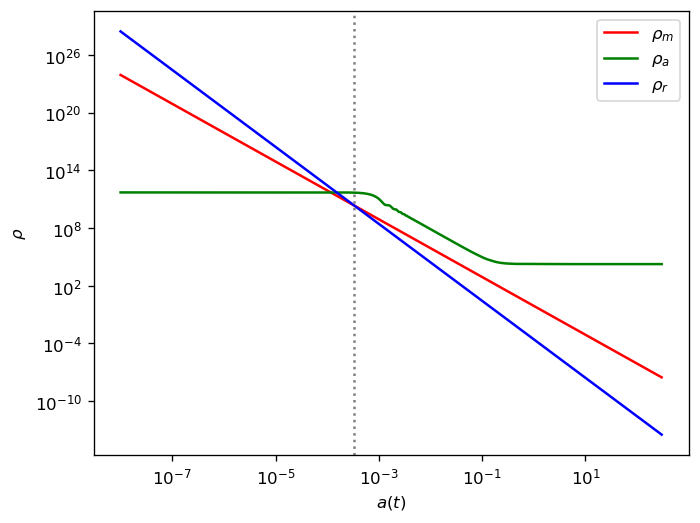

In [4]:
rhoa01 = y[:,2] * 1e2
rhoa_0 = y[:,2].astype(np.float32)
pressure = (-0.5*ma_array[:]**2*y[:,0][:]**2 + 0.5*y[:,1][:]**2)
w = pressure/rhoa01
rhom01 = rho_m0/y[:,-1][:]**3
rhor01 = rho_r0/y[:,-1][:]**4
rhol01 = np.array(rhol)
rhom = np.array(rhom01)
rhol = np.array(rhol01)
rhor = np.array(rhor01)
rhoa = np.array(rhoa01)
rhosum = rhom+rhol+rhor+rhoa
H = (1/np.sqrt(3))*np.sqrt(rhosum[0:1000])
z = 1/y[:,-1][:] - 1

plt.figure(dpi=120)
plt.plot(y[:,-1][:],rhom,label=r'$\rho_m$',color='red')
plt.plot(y[:,-1][:],rhoa,label=r'$\rho_a$',color='green')
plt.plot(y[:,-1][:],rhor,label=r'$\rho_r$',color='blue')
# plt.plot(y[:,-1][:],rhosum,label=r'$\rho_{sum}$',color='black')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('$a(t)$')
plt.ylabel(r'$\rho $');
plt.legend(loc='upper right')
plt.axvline(x=3.35e-4, color="grey", linestyle=":")
# plt.xlim(0.0001,0.001)
# plt.ylim(1e10,1e11)
# plt.grid(True)
plt.show()

Shift Factor (lambda): 7.9412e-05


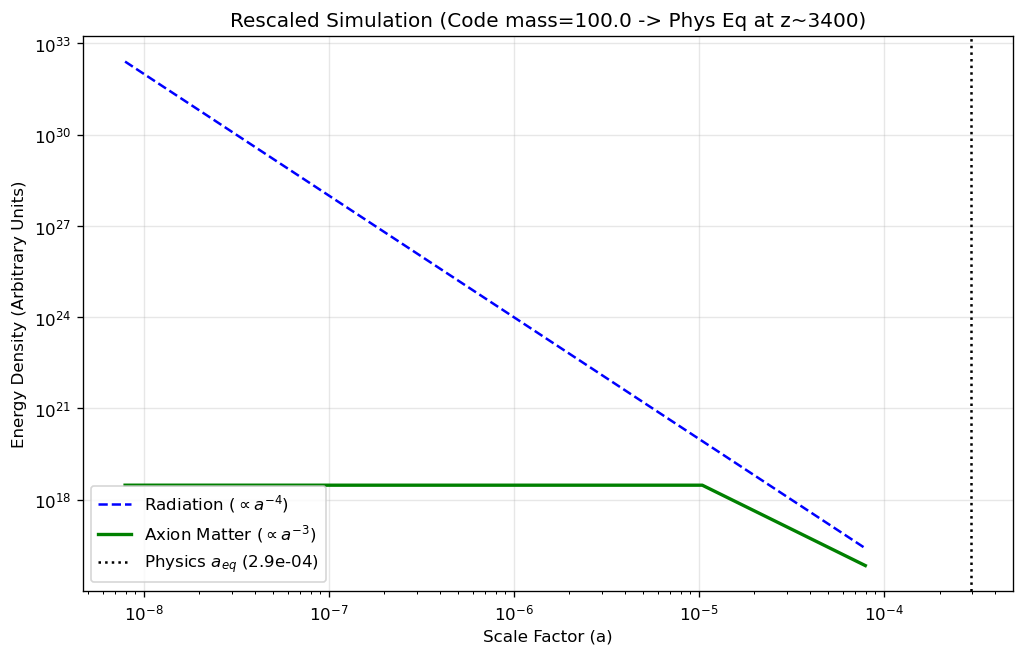

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import brentq

# --- 1. Simulation ใน "โลกย่อส่วน" (Code Units) ---
# ใช้ค่าที่คำนวณง่าย คอมพิวเตอร์ชอบ
ma_code = 100.0       
rho_r_code = 1.0      # สมมติให้ Radiation เป็น 1 ไปเลยเพื่อความง่าย
rho_m_code = 0.0      # เราจะเอา Axion มาแทน Matter
rho_target_ratio = 0.81 / 3.0 # สัดส่วน Matter/Crit ที่ต้องการ (เช่น 0.27)

# หา phi_in ในโลกย่อส่วน (Shooting หรือ สูตรก็ได้)
# สูตร: phi = sqrt( 2 * rho_target / (sqrt(m) * (3*rho_r)^0.75) )
phi_in_code = np.sqrt( (2 * rho_target_ratio) / (np.sqrt(ma_code) * (3*rho_r_code)**0.75) )

# รัน Simulation (ใช้โค้ดเดิมของคุณ)
# ... สมมติรันเสร็จได้ผลลัพธ์ในตัวแปร: a_sim, rho_a_sim, rho_r_sim ...
# (ผมจำลองข้อมูลสมมติเพื่อแสดงวิธี Plot)
a_sim = np.logspace(-4, 0, 1000)
a_osc_sim = (3*rho_r_code/ma_code**2)**0.25 # จุดสั่นใน code ~ 0.13
rho_a_sim = np.where(a_sim < a_osc_sim, 
                     0.5*ma_code**2*phi_in_code**2, 
                     (0.5*ma_code**2*phi_in_code**2)*(a_osc_sim/a_sim)**3)
rho_r_sim = rho_r_code / a_sim**4

# --- 2. การแปลงสู่ "โลกความเป็นจริง" (Physical Rescaling) ---

# กำหนดจุด Equality จริงที่เราต้องการ (เช่น z_eq = 3400 -> a_eq = 1/3400)
a_eq_phys = 1.0 / 3400.0

# หาจุด Equality ใน Code (จุดที่ rho_a ตัดกับ rho_r)
# ใน Code เราตั้ง rho_a สุดท้าย = rho_m ดังนั้นจุดตัดคือ
a_eq_code = rho_r_code / rho_target_ratio 

# คำนวณ Shift Factor (lambda)
shift_factor = a_eq_phys / a_eq_code
print(f"Shift Factor (lambda): {shift_factor:.4e}")

# --- 3. แปลงค่าเพื่อพล็อตกราฟ ---
a_final_plot = a_sim * shift_factor           # ย้ายแกน X (เวลา)
rho_factor = (1.0 / shift_factor)**4          # ตัวคูณแกน Y (ความหนาแน่น)

rho_a_final = rho_a_sim * rho_factor
rho_r_final = rho_r_sim * rho_factor

# --- 4. Plot ---
plt.figure(figsize=(10, 6), dpi=120)

plt.loglog(a_final_plot, rho_r_final, 'b--', label=r'Radiation ($\propto a^{-4}$)')
plt.loglog(a_final_plot, rho_a_final, 'g-', linewidth=2, label=r'Axion Matter ($\propto a^{-3}$)')

# เส้นอ้างอิงตำแหน่ง a_eq
plt.axvline(x=a_eq_phys, color='k', linestyle=':', label=f'Physics $a_{{eq}}$ ({a_eq_phys:.1e})')

plt.xlabel('Scale Factor (a)')
plt.ylabel('Energy Density (Arbitrary Units)')
plt.title(f'Rescaled Simulation (Code mass={ma_code} -> Phys Eq at z~3400)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Estimated Oscillation starts at a ~ 1.69e-05
Setting simulation start at ain = 1.69e-07


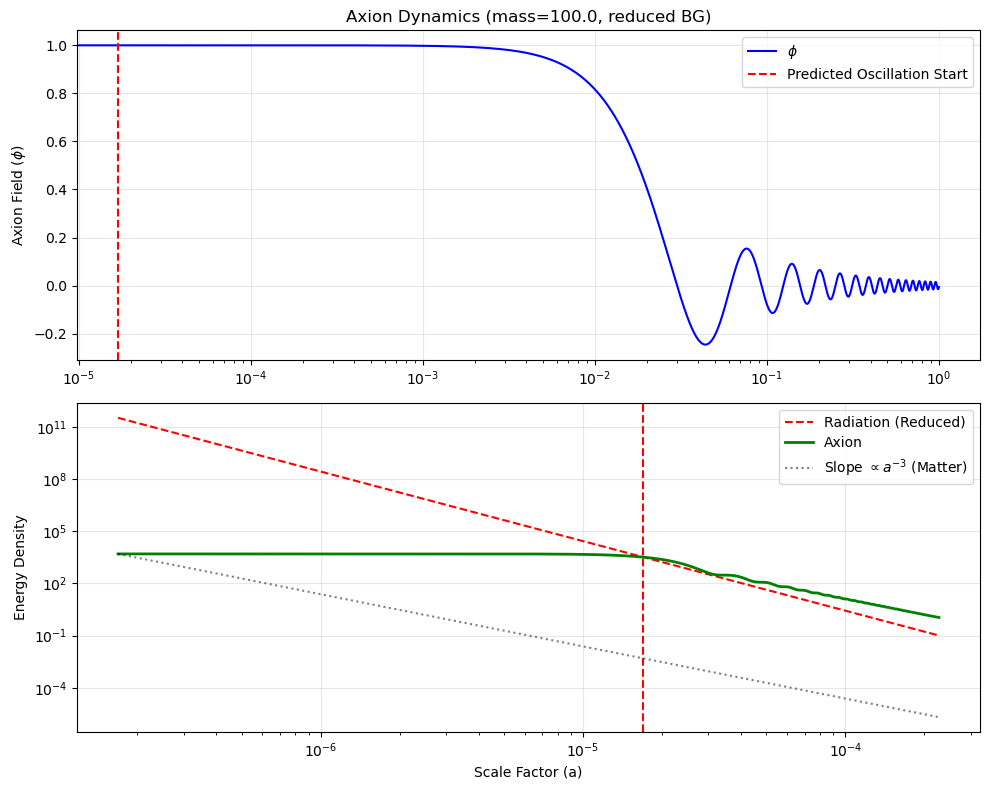

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ==========================================
# 1. ตั้งค่าพารามิเตอร์ (Configuration)
# ==========================================
# ค่าคงที่ Axion
ma0 = 100.0           # มวลเท่าเดิม
phi_in_val = 1.0      # ค่าเริ่มต้นสนาม
phidotin = 0.0

# --- ปรับลด Background เพื่อให้สั่นเร็ว ---
# ลดลงเยอะๆ เพื่อให้ H ต่ำลง จน m=100 เอาชนะได้ตั้งแต่ a เล็กๆ
reduction_factor = 1e-12 

rho_r0_base = 0.00027138
rho_l0_base = 2.19

# ค่าที่ใช้จริงใน Code
rho_r0 = rho_r0_base * reduction_factor
rho_l0 = rho_l0_base * reduction_factor
rho_m0 = 0.0  # ไม่มี Matter อื่น

# ==========================================
# 2. คำนวณจุดเริ่มต้น (Auto-Tune ain) **สำคัญ**
# ==========================================
# หาว่าด้วยค่า rho นี้ และ m=100 มันจะเริ่มสั่นที่ a เท่าไหร่?
# เงื่อนไขเริ่มสั่น: m ~ 3H  =>  m ~ 3 * sqrt(rho_r/3) => m ~ sqrt(3*rho_r0)/a^2
# a_osc ~ (3 * rho_r0 / m^2)^(1/4)

a_osc_estimate = (3 * rho_r0 / ma0**2)**0.25
print(f"Estimated Oscillation starts at a ~ {a_osc_estimate:.2e}")

# **ตั้งค่า ain ให้เล็กกว่าจุดสั่น 100 เท่า** เพื่อให้เห็นช่วง Frozen ชัดๆ
ain = a_osc_estimate / 100.0
print(f"Setting simulation start at ain = {ain:.2e}")

# เตรียม Initial Conditions
rho_ax_in = 0.5 * phidotin**2 + 0.5 * ma0**2 * phi_in_val**2
y0 = [phi_in_val, phidotin, rho_ax_in, ain]

# ==========================================
# 3. สมการฟิสิกส์
# ==========================================
def deriv(y, t, ma0, rho_r0, rho_l0):
    phi, phi_dot, rho_ax, a = y
    
    rho_r = rho_r0 / a**4
    rho_l = rho_l0 
    rho_total = rho_ax + rho_r + rho_l
    
    H = np.sqrt(rho_total / 3.0)
    
    d_phi = phi_dot
    d_phi_dot = -3 * H * phi_dot - (ma0**2) * phi
    d_rho_ax = -3 * H * phi_dot**2 
    d_a = a * H
    
    return [d_phi, d_phi_dot, d_rho_ax, d_a]

# ==========================================
# 4. รัน Simulation
# ==========================================
# เวลาใน Code (t) ต้องรันนานพอให้ a ขยายตัว
t = np.linspace(0, 1, 10000) # ปรับ t_end ให้สั้นลงเพราะเราเริ่มที่ a เล็กมาก

sol = odeint(deriv, y0, t, args=(ma0, rho_r0, rho_l0))

a_sim = sol[:, 3]
phi_sim = sol[:, 0]
rho_a_sim = sol[:, 2]

# ==========================================
# 5. Plot ผลลัพธ์
# ==========================================
plt.figure(figsize=(10, 8), dpi=100)

# Plot 1: ดูพฤติกรรมสนาม (phi)
plt.subplot(2, 1, 1)
# plt.plot(a_sim, phi_sim, 'b-', label=r'$\phi$')
plt.plot(t, phi_sim, 'b-', label=r'$\phi$')
plt.axvline(x=a_osc_estimate, color='r', linestyle='--', label='Predicted Oscillation Start')
plt.xscale('log')
plt.ylabel(r'Axion Field ($\phi$)')
plt.title(f'Axion Dynamics (mass={ma0}, reduced BG)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: ดูความหนาแน่นเทียบกับ Radiation
plt.subplot(2, 1, 2)
rho_r_sim = rho_r0 / a_sim**4
plt.loglog(a_sim, rho_r_sim, 'r--', label='Radiation (Reduced)')
plt.loglog(a_sim, rho_a_sim, 'g-', linewidth=2, label='Axion')

# เช็ค slope ว่าเป็น Matter หรือยัง
plt.loglog(a_sim, rho_a_sim[0] * (a_sim[0]/a_sim)**3, 'k:', label=r'Slope $\propto a^{-3}$ (Matter)', alpha=0.5)

plt.axvline(x=a_osc_estimate, color='r', linestyle='--')
plt.xlabel('Scale Factor (a)')
plt.ylabel('Energy Density')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Simulation Mass: 100.0
Target Mass:     1000000.0
Shift Factor:    0.01


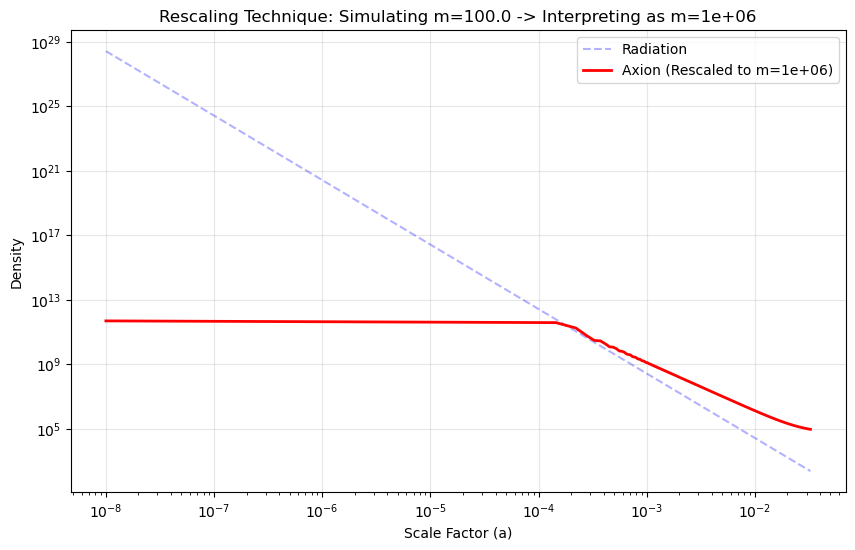

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --- 1. Simulation (ใช้ค่าที่คำนวณง่าย) ---
ma_sim = 100.0        # มวลในโค้ด (น้อยๆ)
rho_r0 = 0.00027138
rho_l0 = 0.0          # ปิด DE ไปก่อนเพื่อความง่ายในช่วงต้น
rho_m0 = 0.0          # ปิด Matter

# Initial Conditions สำหรับ Sim
# (ตั้งมั่วๆ ไปก่อน หรือใช้สูตรคำนวณก็ได้)
phi_in_sim = 1.0      
y0 = [phi_in_sim, 0.0, 0.5*ma_sim**2*phi_in_sim**2, 1e-6]
t = np.linspace(0, 50, 5000)

# ฟังก์ชันเดิม (Clean version)
def deriv_clean(y, t, ma_array, rho_m0, rho_r0, rhol):
    phi, phi_dot, rho_ax, a = y
    rho_r = rho_r0 / a**4
    rho_total = rho_ax + rho_r
    H = np.sqrt(rho_total / 3.0)
    d_phi = phi_dot
    d_phi_dot = -3 * H * phi_dot - (ma_array[0]**2) * phi
    d_rho_ax = -3 * H * phi_dot**2
    d_a = a * H
    return [d_phi, d_phi_dot, d_rho_ax, d_a]

# รัน!
sol = odeint(deriv_clean, y0, t, args=(np.array([ma_sim]), rho_m0, rho_r0, rho_l0))
a_sim = sol[:, 3]
rho_a_sim = sol[:, 2]

# --- 2. Rescaling (แปลงร่างเป็น m = 1,000,000) ---
ma_target = 1.0e6     # มวลเป้าหมาย (เยอะๆ)

# คำนวณตัวคูณ (Shift Factor)
# จากความสัมพันธ์ a_osc ~ 1/sqrt(m)
shift_factor = np.sqrt(ma_sim / ma_target)

print(f"Simulation Mass: {ma_sim}")
print(f"Target Mass:     {ma_target}")
print(f"Shift Factor:    {shift_factor}")

# สร้างแกนใหม่ (Physical Axis)
a_physical = a_sim * shift_factor

# ปรับค่า Density (สำคัญ!)
# rho ~ m^2 * phi^2 
# เพื่อรักษาความสัมพันธ์ของกราฟ เราต้องสเกลความหนาแน่นให้สอดคล้องกับ a ใหม่
# ในยุค Radiation: rho ต้องเพิ่มขึ้นตาม (1/shift)^4
rho_scaling = (1.0 / shift_factor)**4
rho_a_physical = rho_a_sim * rho_scaling

# --- 3. Plot เปรียบเทียบ ---
plt.figure(figsize=(10, 6), dpi=100)

# เส้น Radiation อ้างอิง
rho_r_ref = rho_r0 / a_physical**4
plt.loglog(a_physical, rho_r_ref, 'b--', label='Radiation', alpha=0.3)

# พล็อตผลลัพธ์
plt.loglog(a_physical, rho_a_physical, 'r-', linewidth=2, label=f'Axion (Rescaled to m={ma_target:.0e})')

# เส้นเปรียบเทียบ (ถ้าเราไม่ต้อง Rescale มันจะอยู่ตรงไหน?)
# (พล็อตแบบ Raw data จาก Sim เทียบกับแกนที่ยังไม่เลื่อน)
# plt.loglog(a_sim, rho_a_sim, 'k:', label=f'Raw Sim (m={ma_sim})', alpha=0.5)

plt.xlabel('Scale Factor (a)')
plt.ylabel('Density')
plt.title(f'Rescaling Technique: Simulating m={ma_sim} -> Interpreting as m={ma_target:.0e}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [77]:
mo = 3
c =  1.0
n =  1
N =  1000000
n_cross = 2 
a0 = 1.0
sa = 0.1 
b0 =  1.0
sb =  0.1
s1 =  0.1
s2 = 1.5
phi_range = np.pi  
phidotin = 0.0
# ain = 0.00000001
ain = 1e-8
afi = 1.0
rhocrit = 3.0 
rho_m0 = 0 #0.81 
scaling_factor = 100#1e-10
rho_r0 = 0.00027138 * scaling_factor
rho_l0 = 2.19 * scaling_factor
rhol = rho_l0 
t_in = 0.0
t_fi = 1.0
t = np.linspace(t_in, t_fi, N)

# axion mass
ma0 = 1e2

rho_target = 0.81
term_rad = (3 * rho_r0)**0.75
phi_in_calc = np.sqrt( (2 * rho_target) / (np.sqrt(ma0) * term_rad) )

[5314.479048345419]
[1.030968384417817, 0.0, 5314.479048345419, 1e-08]


<IPython.core.display.Math object>

1.0 0.0 5314.479048345419 1e-08


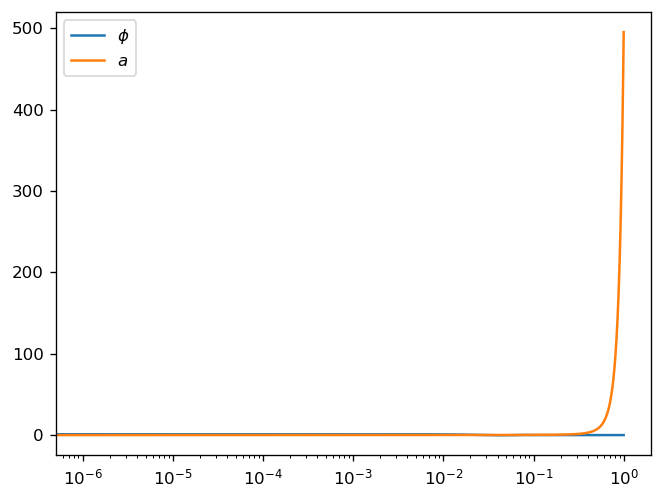

axion mass [100.]


In [82]:
def diag(mo,c,n,a0,b0,sa,sb,s1,s2,phi_range,phidotin):
	if mo == 3:

        ######################################
		####          Kahler              ####
		######################################

		k = (a0/np.random.uniform(s1,s2,(n,n))) #random matrix k from log normal distribution
		kT = k.transpose() # transpose of random matrix k
		k2 = np.dot(k,kT)  # Construction of symmeterised Kahler matric for real axion fields
		ev,pT = np.linalg.eigh(k2) # calculation of eigen values and eigen vectors
		fef = np.sqrt(ev)
		p = pT.transpose() # tranpose of rotational matrix constructed of eigen vectors
		kD = reduce(np.dot, [p, k2, pT]) #diagonalisation of Kahler metric
		kD[kD < 1*10**-13] = 0 # removal of computational error terms in off diagonal elements
		kDr = np.zeros((n, n))#creation of empty 3x3 matrix
		np.fill_diagonal(kDr, (1/((2**0.5)*np.sqrt(ev))))# matrix for absolving eigen values of kahler metric into axion fields
		#kDr[kDr > 1*10**23] = 0 # remove computational errors in reciprocal matrix
		kDrT = kDr.transpose() # trasnpose of kDr matrix

		######################################
		####            Mass              ####
		######################################

		m = (np.random.uniform(np.log(b0)-sb,np.log(b0)+sb,(n,n))) #random matrix m from log normal distribution
		mm = np.exp(-m)
		mT = mm.transpose() # transpose of random matrix m
		m2 = np.dot(mm,mT) # symmeterised mass matrix from real axion fields
		mn = reduce(np.dot, [pT,kDrT, m2, kDr,p]) # correct mass matrix caclulation
		ma_array,mv = np.linalg.eigh(mn) # reout of masses from eigenvalues of mn


	phiin_array = rd.uniform(-phi_range,phi_range,n)

	for i in range (0,n):
		phiin_array[i] = phiin_array[i]*fef[i]
	phiin_array=np.dot(mv,phiin_array)

	phidotin_array = [phidotin]*n #### array of phidotin where all are set equal to zero

	####################################################################
	####################################################################

		
	return ma_array,fef,phiin_array,phidotin_array

def rhoinitial(phidotin_array,phiin_array,ma_array,n):
    rhoin_array=[]
#     print(phidotin_array,phiin_array,ma_array,n)
    for i in range(n):	
        rhoin_array.append( 0.5*phidotin_array[i]**2 + 0.5*(ma_array[i]**2)*phiin_array[i]**2 )
    return rhoin_array
	
###################################################################	

###################################################################
####                    Initial y array                        ####
###################################################################
	
def yinitial(n,phiin_array,phidotin_array,rhoin_array,ain):
	y0=[]
	for i in range(n):
		y0.append(phiin_array[i])
		y0.append(phidotin_array[i])
		y0.append(rhoin_array[i])
	y0.append(ain)
#	print(y0)
	return y0	

def deriv_rho(y,t,n,ma_array,rho_m0,rho_r0,rhol): 
	func=[]
	rho_ax=sum(y[:-1])
	for i in range(n):
		if np.sqrt(3)*np.sqrt(rho_ax + rho_m0/y[-1]**3 + rho_r0/y[-1]**4 + rhol) > 2*(ma_array[i]):
			func.append((-3/np.sqrt(3)*np.sqrt(rho_ax + rho_m0/y[-1]**3 + rho_r0/y[-1]**4 + rhol)*(1-1)*(y[i])))
		else:
			func.append((-3/np.sqrt(3)*np.sqrt(rho_ax + rho_m0/y[-1]**3 + rho_r0/y[-1]**4 + rhol)*(y[i])))	
	func.append((1/np.sqrt(3)*np.sqrt(rho_ax*y[-1]**2 + rho_m0/y[-1] + rho_r0/y[-1]**2 + rhol*y[-1]**2)))
	return func



def deriv_wfromphi(y, t, n, n_cross, ma_array, rho_m0, rho_r0, rhol):
#def deriv_wfromphi(y, ma_array):
#
    crossing_index = [0]*n
    func = []
    rho_ax = sum(y[2::3])  # ใช้ y แทน y ในการเข้าถึงค่าตัวแปร
#
    for i in range(n):
        if (crossing_index[i] % 2 == 0 and ma_array[i] * y[3*i] * y[3*i] < y[3*i+1] * y[3*i+1] and y[3*i+1] > 0) or \
           (crossing_index[i] % 2 == 1 and ma_array[i] * y[3*i] * y[3*i] > y[3*i+1] * y[3*i+1] and y[3*i+1] < 0):
            crossing_index[i] += 1
        
        func.append(y[3*i+1])  
        if crossing_index[i] < n_cross:
            func.append((-np.sqrt(3) * (np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol)) * y[3*i+1] - (ma_array[i]**2) * y[3*i]))
        else:
            func.append(-np.sqrt(3) * (np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol)) * y[3*i+1])
        
        if crossing_index[i] < n_cross:
            func.append(-3 / np.sqrt(3) * np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol) * y[3*i+1]**2)
        else:
            func.append(-3 / np.sqrt(3) * np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol) * y[3*i+2])

    func.append((1 / np.sqrt(3) * np.sqrt(rho_ax * (y[-1])**2 + rho_m0 / y[-1] + rho_r0 / y[-1]**2 + rhol * (y[-1])**2)))

#     print(crossing_index)

    return func

def eq(y,t):
    return deriv_wfromphi(y,t,n,n_cross,ma_array,rho_m0,rho_r0,rhol)


ma_array, fef, phiin_array, phidotin_array = diag(mo, c, n, a0, b0, sa, sb, s1, s2, phi_range, phidotin)
ma_array = np.array([ma0])
# phiin_array = np.array([1.0])
phiin_array = np.array([phi_in_calc])
rhoin_array = rhoinitial(phidotin_array, phiin_array, ma_array, n)
# print(rhoin_array)
# rhoin_array = np.array([5000])

print(rhoin_array)

# phiin_array = 100000.0
y0 = yinitial(n, phiin_array, phidotin_array, rhoin_array, ain)
print(y0)
phi_in,dphi_in,rho_in,a_in=y0
phi_in = 1.0
display(Math(r'$ \phi_0, \dot{\phi_0}, \rho_0, a_0 $'))
print(phi_in,dphi_in,rho_in,a_in)


t = np.linspace(t_in,t_fi,N)
y = odeint(eq,y0,t,mxstep=int(1e9))

# set phi_0 = 0
# y[:,0] = 0.0

uuut = t 
uuuy = y
# print(y)
#print('uuuy')
# print(uuuy[:,0])
plt.figure(dpi=120)
plt.plot(uuut,uuuy[:,0],label = r'$\phi$')
# plt.plot(uuut,uuuy[:,1],label = r'$\dot{\phi}$')
# plt.plot(uuut,uuuy[:,2],label = r'$\rho_{a}$')
plt.plot(uuut,uuuy[:,3],label = r'$a$')
# plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()
print("axion mass",ma_array)
# print(rhol)

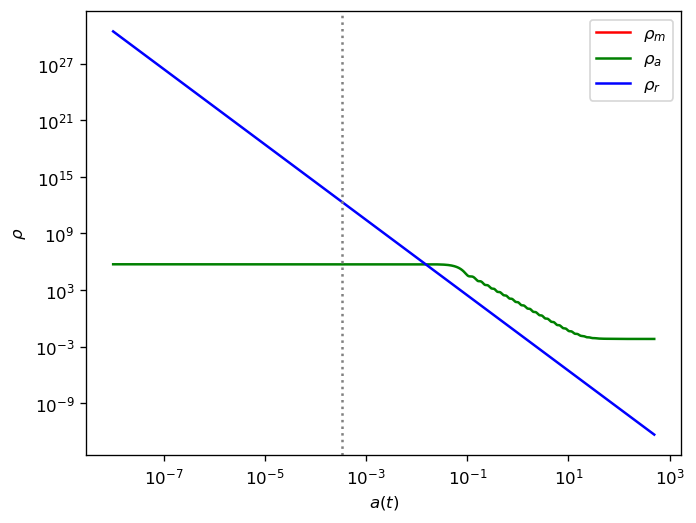

In [79]:
rhoa01 = y[:,2] * 1e2
rhoa_0 = y[:,2].astype(np.float32)
pressure = (-0.5*ma_array[:]**2*y[:,0][:]**2 + 0.5*y[:,1][:]**2)
w = pressure/rhoa01
rhom01 = rho_m0/y[:,-1][:]**3
rhor01 = rho_r0/y[:,-1][:]**4
rhol01 = np.array(rhol)
rhom = np.array(rhom01)
rhol = np.array(rhol01)
rhor = np.array(rhor01)
rhoa = np.array(rhoa01)
rhosum = rhom+rhol+rhor+rhoa
H = (1/np.sqrt(3))*np.sqrt(rhosum[0:1000])
z = 1/y[:,-1][:] - 1

plt.figure(dpi=120)
plt.plot(y[:,-1][:],rhom,label=r'$\rho_m$',color='red')
plt.plot(y[:,-1][:],rhoa,label=r'$\rho_a$',color='green')
plt.plot(y[:,-1][:],rhor,label=r'$\rho_r$',color='blue')
# plt.plot(y[:,-1][:],rhosum,label=r'$\rho_{sum}$',color='black')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('$a(t)$')
plt.ylabel(r'$\rho $');
plt.legend(loc='upper right')
plt.axvline(x=3.35e-4, color="grey", linestyle=":")
# plt.xlim(0.0001,0.001)
# plt.ylim(1e10,1e11)
# plt.grid(True)
plt.show()

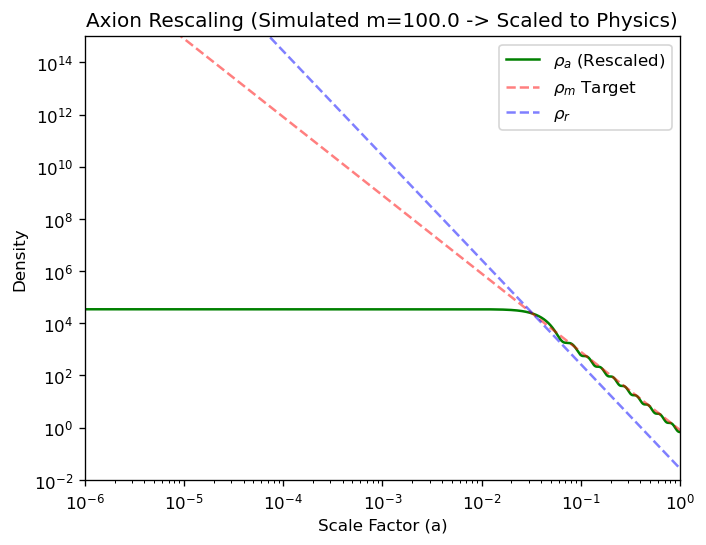

In [80]:
uuuy = y


a_osc_sim = (3 * rho_r0 / ma0**2)**0.25

a_eq_target = rho_r0 / rho_target 

shift_factor = a_eq_target / a_osc_sim

a_sim = uuuy[:, 3]
a_physical = a_sim * shift_factor


rho_a_sim = uuuy[:, 2]
rho_a_physical = rho_a_sim * (shift_factor**-4)

plt.figure(dpi=120)

plt.loglog(a_physical, rho_a_physical, 'g-', label=r'$\rho_a$ (Rescaled)')

rho_m_ref = rho_target / a_physical**3
plt.loglog(a_physical, rho_m_ref, 'r--', alpha=0.5, label=r'$\rho_m$ Target')

rho_r_ref = rho_r0 / a_physical**4
plt.loglog(a_physical, rho_r_ref, 'b--', alpha=0.5, label=r'$\rho_r$')

plt.xlabel('Scale Factor (a)')
plt.ylabel('Density')
plt.xlim(1e-6, 1) 
plt.ylim(1e-2, 1e15)
plt.legend()
plt.title(f'Axion Rescaling (Simulated m={ma0} -> Scaled to Physics)')
plt.show()